In [44]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

**Load training set**

In [3]:
training_set = pd.read_csv(r'C:\caocao\gnw-master\ANN\data_timeseries\training set\training.csv', index_col=0)

In [4]:
training_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,qseB,flhD,1,0.758564,0.720131,0.698485,0.819815,0.860162,...,0.787758,0.764081,0.708287,0.621720,0.633755,0.691102,0.590845,0.648797,0.693195,0.605606
1,10,0,qseB,qseC,1,0.758564,0.720131,0.698485,0.819815,0.860162,...,0.555048,0.579293,0.523600,0.631898,0.588495,0.602070,0.555735,0.679805,0.602104,0.573019
2,10,0,flhD,flgB,1,0.711474,0.606464,0.743402,0.757836,0.638821,...,0.483193,0.479332,0.377493,0.512925,0.496020,0.463000,0.354173,0.516397,0.429662,0.498837
3,10,0,flhD,flgH,1,0.711474,0.606464,0.743402,0.757836,0.638821,...,0.724486,0.679557,0.725365,0.661475,0.693318,0.804668,0.808074,0.675003,0.682815,0.617701
4,10,0,flhD,gltK,1,0.711474,0.606464,0.743402,0.757836,0.638821,...,0.500213,0.483350,0.514881,0.523799,0.604483,0.611427,0.534869,0.582119,0.437258,0.556299


**Training set information**

In [5]:
training_set.shape

(1815000, 107)

In [6]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1815000 entries, 0 to 1814999
Columns: 107 entries, size to t_step50
dtypes: float64(102), int64(3), object(2)
memory usage: 1.5+ GB


**Load validation set**

In [7]:
validation_set = pd.read_csv(r'C:\caocao\gnw-master\ANN\data_timeseries\validation set\validation.csv', index_col=0)
validation_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,nsrR,dsdC,1,0.657365,0.67215,0.716318,0.615248,0.677873,...,0.402555,0.327725,0.381153,0.430556,0.370586,0.348197,0.307246,0.406686,0.350204,0.341552
1,10,0,nsrR,norR,1,0.657365,0.67215,0.716318,0.615248,0.677873,...,0.004510,0.011817,0.005464,0.008301,0.013001,0.005855,0.017393,0.007097,0.010025,0.006172
2,10,0,nsrR,feaR,1,0.657365,0.67215,0.716318,0.615248,0.677873,...,0.032079,0.019488,0.049370,0.037082,0.023262,0.021760,0.020839,0.011537,0.039281,0.062861
3,10,0,nsrR,feaB,1,0.657365,0.67215,0.716318,0.615248,0.677873,...,0.317695,0.267817,0.258661,0.259308,0.271263,0.330887,0.307273,0.260060,0.338651,0.283529
4,10,0,nsrR,rffM,1,0.657365,0.67215,0.716318,0.615248,0.677873,...,0.143187,0.131153,0.139580,0.109291,0.124466,0.105313,0.141195,0.123628,0.129988,0.151730


**Validation set information**

In [8]:
validation_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 363000 entries, 0 to 362999
Columns: 107 entries, size to t_step50
dtypes: float64(102), int64(3), object(2)
memory usage: 299.1+ MB


**Load test set**

In [10]:
test_set = pd.read_csv(r'C:\caocao\gnw-master\ANN\data_timeseries\test set\test.csv', index_col=0)
test_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step41,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50
0,10,0,gadX,gadW,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.182667,0.106119,0.148716,0.169888,0.162320,0.158062,0.171469,0.195182,0.171420,0.160383
1,10,0,gadX,hdeA,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.425638,0.367995,0.382267,0.385295,0.340654,0.530782,0.473160,0.417737,0.388315,0.417774
2,10,0,gadX,hdeB,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.392642,0.441659,0.346970,0.383288,0.398148,0.342651,0.505598,0.440033,0.384702,0.530069
3,10,0,gadX,yhiD,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.528250,0.605339,0.539309,0.528559,0.521410,0.597797,0.541800,0.523565,0.474665,0.487404
4,10,0,gadX,gadA,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.322860,0.330985,0.423989,0.452562,0.401386,0.430852,0.420349,0.491919,0.311109,0.352580


**Test set information**

In [11]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 363000 entries, 0 to 362999
Columns: 107 entries, size to t_step50
dtypes: float64(102), int64(3), object(2)
memory usage: 299.1+ MB


In [13]:
data = pd.concat([size10, size50, size100], ignore_index=False)
data.shape

(206000, 107)

**Data preparation**

In [30]:
training_set['size'] = training_set['size'].astype(str)
validation_set['size'] = validation_set['size'].astype(str)
test_set['size'] = test_set['size'].astype(str)

In [31]:
training_dummies = pd.get_dummies(training_set, columns=['size'])
X_train = training_dummies.drop(['sample', 'regulator', 'target', 'interaction'], axis=1).values
y_train = training_dummies['interaction'].values

In [45]:
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)

In [32]:
X_train.shape

(1815000, 105)

In [42]:
type(X_train)

numpy.ndarray

In [33]:
X_train

array([[0.7585644, 0.7201306, 0.6984852, ..., True, False, False],
       [0.7585644, 0.7201306, 0.6984852, ..., True, False, False],
       [0.711474, 0.6064643, 0.7434015, ..., True, False, False],
       ...,
       [0.1537719, 0.1602146, 0.1859554, ..., False, True, False],
       [0.1537719, 0.1602146, 0.1859554, ..., False, True, False],
       [0.1537719, 0.1602146, 0.1859554, ..., False, True, False]],
      dtype=object)

In [34]:
y_train.shape

(1815000,)

In [35]:
validation_dummies = pd.get_dummies(validation_set, columns=['size'])
X_validation = validation_dummies.drop(['sample', 'regulator', 'target', 'interaction'], axis=1).values
y_validation = validation_dummies['interaction'].values

In [46]:
X_validation = np.asarray(X_validation).astype(np.float32)
y_validation = np.asarray(y_validation).astype(np.float32)

In [36]:
X_validation.shape

(363000, 105)

In [37]:
y_validation.shape

(363000,)

In [38]:
test_dummies = pd.get_dummies(test_set, columns=['size'])
X_test = test_dummies.drop(['sample', 'regulator', 'target', 'interaction'], axis=1).values
y_test = test_dummies['interaction'].values

In [47]:
X_test = np.asarray(X_test).astype(np.float32)
y_test = np.asarray(y_test).astype(np.float32)

In [39]:
X_test.shape

(363000, 105)

In [40]:
y_test.shape

(363000,)

**Build the model**

In [101]:
model = keras.models.Sequential([ 
    keras.layers.Dense(1024, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
model.compile(loss="mean_squared_error", optimizer="sgd", metrics=['accuracy'])

In [102]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_validation, y_validation), 
                    callbacks=[early_stopping_cb])

Epoch 1/100
56719/56719 [==============================] - 267s 5ms/step - loss: 0.0354 - accuracy: 0.9629 - val_loss: 0.0374 - val_accuracy: 0.9576
Epoch 2/100
56719/56719 [==============================] - 268s 5ms/step - loss: 0.0341 - accuracy: 0.9630 - val_loss: 0.0369 - val_accuracy: 0.9579
Epoch 3/100
56719/56719 [==============================] - 269s 5ms/step - loss: 0.0340 - accuracy: 0.9631 - val_loss: 0.0363 - val_accuracy: 0.9595
Epoch 4/100
56719/56719 [==============================] - 264s 5ms/step - loss: 0.0339 - accuracy: 0.9631 - val_loss: 0.0371 - val_accuracy: 0.9586
Epoch 5/100
56719/56719 [==============================] - 259s 5ms/step - loss: 0.0339 - accuracy: 0.9632 - val_loss: 0.0379 - val_accuracy: 0.9583
Epoch 6/100
56719/56719 [==============================] - 254s 4ms/step - loss: 0.0338 - accuracy: 0.9632 - val_loss: 0.0370 - val_accuracy: 0.9589
Epoch 7/100
56719/56719 [==============================] - 258s 5ms/step - loss: 0.0338 - accuracy: 0.9632

**Tunning hyperparameters**

In [ ]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[105]): 
    model = keras.models.Sequential() 
    options = {"input_shape": input_shape} 
    for layer in range(n_hidden): 
        model.add(keras.layers.Dense(n_neurons, activation="relu", **options)) 
        options = {}
    model.add(keras.layers.Dense(1, **options)) 
    optimizer = keras.optimizers.SGD(learning_rate) 
    model.compile(loss="mse", optimizer=optimizer) 
    return model

In [ ]:
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
keras_reg = KerasRegressor(build_model)

In [ ]:
from scipy.stats import reciprocal 
from sklearn.model_selection import RandomizedSearchCV
param_distribs = { "n_hidden": [2, 3, 4, 5], 
                  "n_neurons": [50, 100, 150, 200], 
                  "learning_rate": reciprocal(3e-4, 3e-2),
}
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3) 
rnd_search_cv.fit(X_train, y_train, epochs=100, 
                  validation_data=(X_validation, y_validation), 
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

(0.0, 1.0)

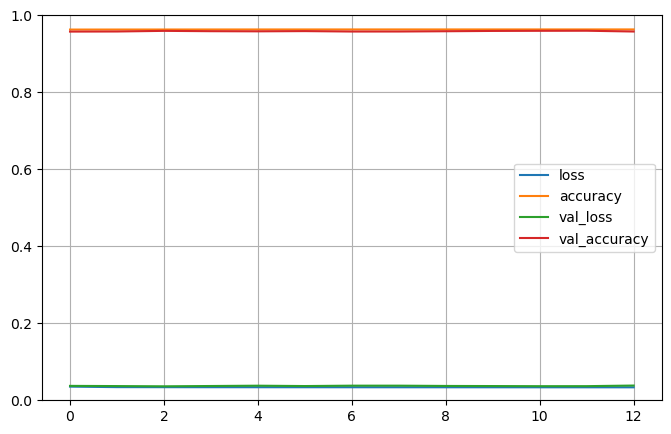

In [103]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5)) 
plt.grid(True)
plt.gca().set_ylim(0, 1)

**Evaluate on the test set**

In [86]:
mse_test = model.evaluate(X_test, y_test)

11344/11344 [==============================] - 18s 2ms/step - loss: 0.0294 - accuracy: 0.9686


In [53]:
mse_test

[0.029739774763584137, 0.9668512344360352]

In [104]:
y_predicted = model.predict(X_test)

11344/11344 [==============================] - 26s 2ms/step


In [105]:
y_predicted

array([[0.05653369],
       [0.04793537],
       [0.04746017],
       ...,
       [0.02747874],
       [0.02675321],
       [0.0270298 ]], dtype=float32)

In [106]:
y_predicted = np.round(y_predicted)
y_predicted

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], dtype=float32)

In [107]:
sum(y_predicted)

array([2613.], dtype=float32)

In [108]:
predicted = pd.Series(y_predicted.ravel())
predicted

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
362995    0.0
362996    0.0
362997    0.0
362998    0.0
362999    0.0
Length: 363000, dtype: float32

In [109]:
test_set['predicted'] = predicted

In [110]:
test_set['predicted'].info()

<class 'pandas.core.series.Series'>
Index: 363000 entries, 0 to 362999
Series name: predicted
Non-Null Count   Dtype  
--------------   -----  
363000 non-null  float32
dtypes: float32(1)
memory usage: 4.2 MB


In [92]:
test_set.head()

,size,sample,regulator,target,interaction,r_step0,r_step1,r_step2,r_step3,r_step4,...,t_step42,t_step43,t_step44,t_step45,t_step46,t_step47,t_step48,t_step49,t_step50,predicted
0,10,0,gadX,gadW,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.106119,0.148716,0.169888,0.162320,0.158062,0.171469,0.195182,0.171420,0.160383,0.0
1,10,0,gadX,hdeA,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.367995,0.382267,0.385295,0.340654,0.530782,0.473160,0.417737,0.388315,0.417774,-0.0
2,10,0,gadX,hdeB,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.441659,0.346970,0.383288,0.398148,0.342651,0.505598,0.440033,0.384702,0.530069,-0.0
3,10,0,gadX,yhiD,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.605339,0.539309,0.528559,0.521410,0.597797,0.541800,0.523565,0.474665,0.487404,0.0
4,10,0,gadX,gadA,1,0.202028,0.265839,0.347388,0.288482,0.264709,...,0.330985,0.423989,0.452562,0.401386,0.430852,0.420349,0.491919,0.311109,0.352580,-0.0


In [93]:
def performance_metrics(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                fp+=1
            else:
                fn+=1
    precision = tp/(tp+fp)
    recall = tp/(tp+fn) if (tp+fn)!=0 else 0
    structural = (tp+tn)/(tp+fp+fn+tn)
    return precision, recall, structural

In [111]:
size = [10, 50, 100]
result={}
for s in size:
    subset = test_set[test_set['size']==str(s)]
    sample = set(subset['sample'].values)
    for sp in sample:
        network = subset[subset['sample']==sp]
        p,r,st = performance_metrics(network['interaction'].values, network['predicted'].values)
        result[f'{s}_{sp}'] = {'precision':round(p, 4), 'recall':round(r,4), 'structural': round(st,4)}

In [112]:
result

{'10_0': {'precision': 0.1333, 'recall': 0.1818, 'structural': 0.7556},
 '10_1': {'precision': 0.3, 'recall': 0.3462, 'structural': 0.7889},
 '10_2': {'precision': 0.2667, 'recall': 0.3077, 'structural': 0.7778},
 '10_3': {'precision': 0.2333, 'recall': 0.28, 'structural': 0.7722},
 '10_4': {'precision': 0.3667, 'recall': 0.3235, 'structural': 0.7667},
 '10_5': {'precision': 0.2, 'recall': 0.2727, 'structural': 0.7778},
 '10_6': {'precision': 0.2333, 'recall': 0.2593, 'structural': 0.7611},
 '10_7': {'precision': 0.2333, 'recall': 0.25, 'structural': 0.7556},
 '10_8': {'precision': 0.2333, 'recall': 0.28, 'structural': 0.7722},
 '10_9': {'precision': 0.2667, 'recall': 0.2581, 'structural': 0.75},
 '10_10': {'precision': 0.3333, 'recall': 0.3448, 'structural': 0.7833},
 '10_11': {'precision': 0.2333, 'recall': 0.2593, 'structural': 0.7611},
 '10_12': {'precision': 0.2667, 'recall': 0.32, 'structural': 0.7833},
 '10_13': {'precision': 0.2333, 'recall': 0.3043, 'structural': 0.7833},
 '10

In [113]:
performance = pd.DataFrame.from_dict(result, orient='index')
performance.to_csv(r'C:\caocao\gnw-master\ANN\data_timeseries\test set\performance.csv')